# Maternal Health Risk Classification Project

Implements KNN, SVM, and MLP with 5-fold stratified cross-validation.

In [52]:

import warnings, os, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

DATA_PATH = "18_Maternal_Health_Risk.csv"  # keep CSV in same folder as notebook
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.head()


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [53]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nClass distribution:")
print(df["RiskLevel"].value_counts())
print("\nDescription:")
df.describe()

Shape: (1014, 7)

Missing values:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

Class distribution:
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

Description:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [54]:
#Remove duplicates
df = df.drop_duplicates()
#Set up label encoder and encode target column
X = df.drop(columns=["RiskLevel"])
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["RiskLevel"])
class_names = list(label_encoder.classes_)

#Set up kfold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


## Visualization
Four scatter plots show pairwise feature relationships with class labels.

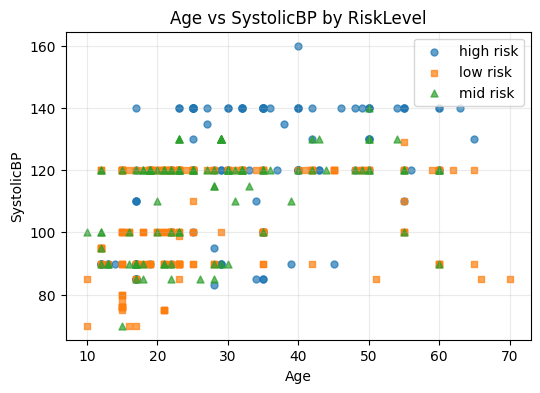

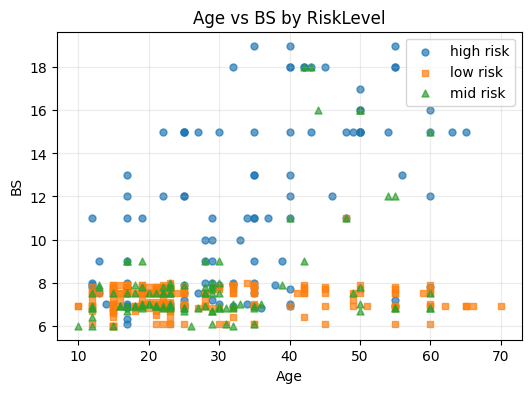

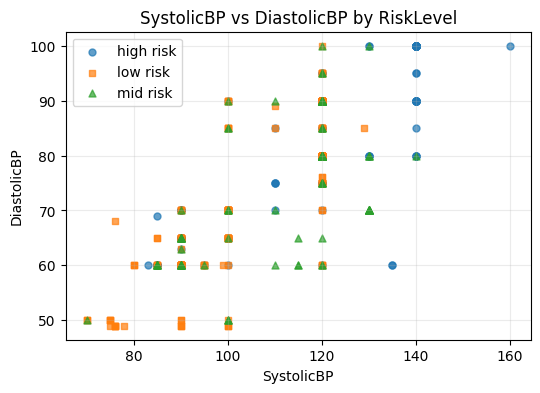

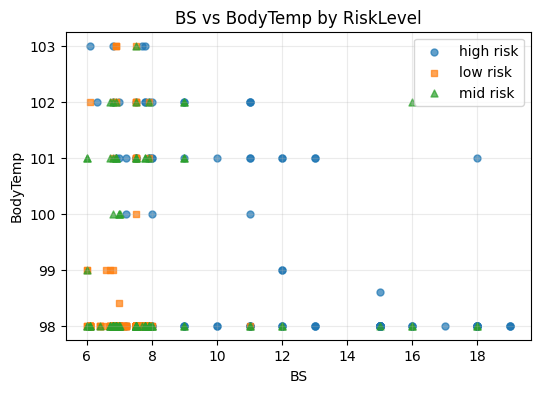

In [55]:

feature_pairs = [("Age","SystolicBP"), ("Age","BS"), ("SystolicBP","DiastolicBP"), ("BS","BodyTemp")]
classes = sorted(df["RiskLevel"].unique())
markers = ["o", "s", "^"]

for x_col, y_col in feature_pairs:
    plt.figure(figsize=(6,4))
    for cls, marker in zip(classes, markers):
        sub = df[df["RiskLevel"] == cls]
        plt.scatter(sub[x_col], sub[y_col], label=cls, marker=marker, alpha=0.7, s=25)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{x_col} vs {y_col} by RiskLevel")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


## Cross-validation and metrics
Sensitivity is macro-average recall. Specificity is computed one-vs-rest for each class then macro-averaged.

In [56]:
X = df.drop(columns=["RiskLevel"])
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["RiskLevel"])
class_names = list(label_encoder.classes_)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metric_columns = ["Accuracy", "Sensitivity", "Specificity", "Precision", "Recall", "F1-score"]

def metrics_from_cm(cm):
    n = cm.sum()
    sensitivity = []
    specificity = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = n - tp - fn - fp
        sensitivity.append(tp / (tp + fn) if (tp + fn) else 0)
        specificity.append(tn / (tn + fp) if (tn + fp) else 0)
    return float(np.mean(sensitivity)), float(np.mean(specificity))

def evaluate_cv(model, X, y, cv):
    rows, cms = [], []
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        clf = clone(model)
        clf.fit(X.iloc[train_idx], y[train_idx])
        pred = clf.predict(X.iloc[test_idx])
        cm = confusion_matrix(y[test_idx], pred, labels=np.arange(len(class_names)))
        sens, spec = metrics_from_cm(cm)
        rows.append({
            "Fold": fold,
            "Accuracy": accuracy_score(y[test_idx], pred),
            "Sensitivity": sens,
            "Specificity": spec,
            "Precision": precision_score(y[test_idx], pred, average="macro", zero_division=0),
            "Recall": recall_score(y[test_idx], pred, average="macro", zero_division=0),
            "F1-score": f1_score(y[test_idx], pred, average="macro", zero_division=0),
        })
        cms.append(cm)
    return pd.DataFrame(rows), np.sum(cms, axis=0)

def summarize_cv_results(fold_table):
    """Return mean ± std for each metric across the 5 folds."""
    summary = []
    for metric in metric_columns:
        summary.append({
            "Metric": metric,
            "Mean": fold_table[metric].mean(),
            "Std": fold_table[metric].std(),
            "Mean ± Std": f"{fold_table[metric].mean():.4f} ± {fold_table[metric].std():.4f}"
        })
    return pd.DataFrame(summary)

def display_cv_results(model_name, fold_table):
    print(f"{model_name} - 5-fold cross-validation results")
    display(fold_table.round(4))
    print(f"{model_name} - mean ± std")
    display(summarize_cv_results(fold_table))

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(4,3.5))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(range(len(class_names)), class_names)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.show()


## KNN
StandardScaler is used because KNN relies on distance. K is selected by mean cross-validation accuracy.

Best K: 9


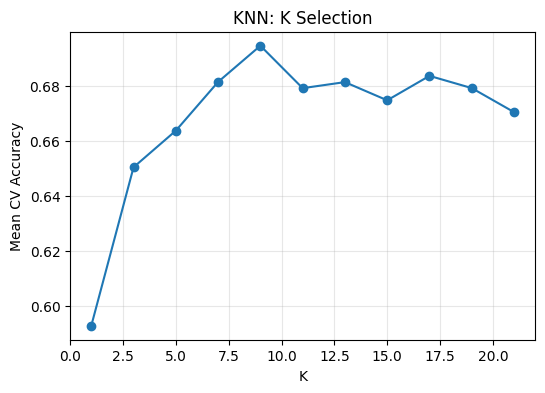

,Fold,Accuracy,Sensitivity,Specificity,Precision,Recall,F1-score
0,1,0.747253,0.664024,0.844754,0.713675,0.664024,0.636781
1,2,0.659341,0.575099,0.798357,0.607377,0.575099,0.571343
2,3,0.677778,0.588637,0.806899,0.619577,0.588637,0.583129
3,4,0.688889,0.605232,0.829114,0.614238,0.605232,0.603635
4,5,0.700000,0.612324,0.828174,0.640351,0.612324,0.613907


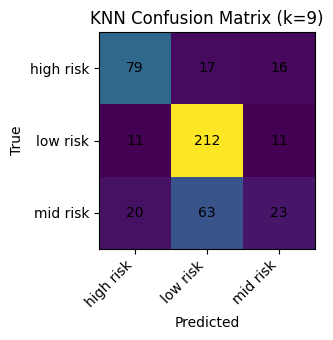

KNN - 5-fold cross-validation results


,Fold,Accuracy,Sensitivity,Specificity,Precision,Recall,F1-score
0,1,0.7473,0.6640,0.8448,0.7137,0.6640,0.6368
1,2,0.6593,0.5751,0.7984,0.6074,0.5751,0.5713
2,3,0.6778,0.5886,0.8069,0.6196,0.5886,0.5831
3,4,0.6889,0.6052,0.8291,0.6142,0.6052,0.6036
4,5,0.7000,0.6123,0.8282,0.6404,0.6123,0.6139


KNN - mean ± std


,Metric,Mean,Std,Mean ± Std
0,Accuracy,0.694652,0.033016,0.6947 ± 0.0330
1,Sensitivity,0.609063,0.033973,0.6091 ± 0.0340
2,Specificity,0.821459,0.018655,0.8215 ± 0.0187
3,Precision,0.639043,0.043499,0.6390 ± 0.0435
4,Recall,0.609063,0.033973,0.6091 ± 0.0340
5,F1-score,0.601759,0.025738,0.6018 ± 0.0257


In [57]:

k_values = list(range(1, 22, 2))
k_scores = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k, metric='euclidean'))
    ])
    fold_table, _ = evaluate_cv(model, X, y, cv)
    k_scores.append(fold_table["Accuracy"].mean())

best_k = k_values[int(np.argmax(k_scores))]
print("Best K:", best_k)

plt.figure(figsize=(6,4))
plt.plot(k_values, k_scores, marker="o")
plt.xlabel("K")
plt.ylabel("Mean CV Accuracy")
plt.title("KNN: K Selection")
plt.grid(alpha=0.3)
plt.show()

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])
knn_results, knn_cm = evaluate_cv(knn_model, X, y, cv)
display(knn_results)
plot_confusion_matrix(knn_cm, f"KNN Confusion Matrix (k={best_k})")
display_cv_results("KNN", knn_results)

## SVM
SVM uses scaling because margins and kernels depend on feature magnitudes. Kernels are compared and RBF is selected.

,Kernel,Accuracy,F1-score
0,linear,0.668132,0.502418
1,poly,0.663761,0.553547
2,rbf,0.694701,0.608618
3,sigmoid,0.553162,0.463666


,Fold,Accuracy,Sensitivity,Specificity,Precision,Recall,F1-score
0,1,0.714286,0.654288,0.841444,0.653846,0.654288,0.645511
1,2,0.670330,0.575099,0.800824,0.636837,0.575099,0.580730
2,3,0.722222,0.625065,0.829214,0.686380,0.625065,0.618529
3,4,0.666667,0.591047,0.822373,0.591206,0.591047,0.589493
4,5,0.700000,0.611602,0.822332,0.655396,0.611602,0.608824


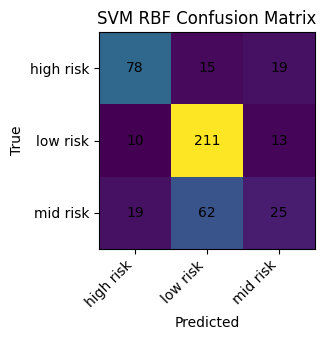

SVM - 5-fold cross-validation results


,Fold,Accuracy,Sensitivity,Specificity,Precision,Recall,F1-score
0,1,0.7143,0.6543,0.8414,0.6538,0.6543,0.6455
1,2,0.6703,0.5751,0.8008,0.6368,0.5751,0.5807
2,3,0.7222,0.6251,0.8292,0.6864,0.6251,0.6185
3,4,0.6667,0.5910,0.8224,0.5912,0.5910,0.5895
4,5,0.7000,0.6116,0.8223,0.6554,0.6116,0.6088


SVM - mean ± std


,Metric,Mean,Std,Mean ± Std
0,Accuracy,0.694701,0.025244,0.6947 ± 0.0252
1,Sensitivity,0.611420,0.030652,0.6114 ± 0.0307
2,Specificity,0.823237,0.014757,0.8232 ± 0.0148
3,Precision,0.644733,0.034852,0.6447 ± 0.0349
4,Recall,0.611420,0.030652,0.6114 ± 0.0307
5,F1-score,0.608618,0.025509,0.6086 ± 0.0255


In [61]:

kernel_rows = []
for kernel in ["linear", "poly", "rbf", "sigmoid"]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel=kernel, C=10, gamma="scale", random_state=42))
    ])
    fold_table, _ = evaluate_cv(model, X, y, cv)
    kernel_rows.append({
        "Kernel": kernel,
        "Accuracy": fold_table["Accuracy"].mean(),
        "F1-score": fold_table["F1-score"].mean()
    })

kernel_table = pd.DataFrame(kernel_rows)
display(kernel_table)

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale", random_state=42))
])
svm_results, svm_cm = evaluate_cv(svm_model, X, y, cv)
display(svm_results)
plot_confusion_matrix(svm_cm, "SVM RBF Confusion Matrix")
display_cv_results("SVM", svm_results)


Support vectors are the training samples closest to the separating boundary. They define the margin; changing them can change the SVM decision boundary.

## Deep Learning MLP
MLP uses two hidden layers: 32 and 16 neurons. ReLU is used in hidden layers; softmax-like multiclass output is handled internally by scikit-learn.

,Fold,Accuracy,Sensitivity,Specificity,Precision,Recall,F1-score
0,1,0.703297,0.588491,0.811497,0.808566,0.588491,0.545686
1,2,0.637363,0.551383,0.788339,0.515432,0.551383,0.503880
2,3,0.666667,0.563262,0.798863,0.602978,0.563262,0.514205
3,4,0.688889,0.586227,0.814295,0.771301,0.586227,0.547263
4,5,0.688889,0.585506,0.811446,0.779769,0.585506,0.530709


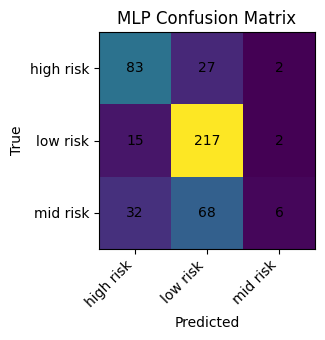

MLP - 5-fold cross-validation results


,Fold,Accuracy,Sensitivity,Specificity,Precision,Recall,F1-score
0,1,0.7033,0.5885,0.8115,0.8086,0.5885,0.5457
1,2,0.6374,0.5514,0.7883,0.5154,0.5514,0.5039
2,3,0.6667,0.5633,0.7989,0.6030,0.5633,0.5142
3,4,0.6889,0.5862,0.8143,0.7713,0.5862,0.5473
4,5,0.6889,0.5855,0.8114,0.7798,0.5855,0.5307


MLP - mean ± std


,Metric,Mean,Std,Mean ± Std
0,Accuracy,0.677021,0.025749,0.6770 ± 0.0257
1,Sensitivity,0.574974,0.016688,0.5750 ± 0.0167
2,Specificity,0.804888,0.011015,0.8049 ± 0.0110
3,Precision,0.695609,0.129050,0.6956 ± 0.1291
4,Recall,0.574974,0.016688,0.5750 ± 0.0167
5,F1-score,0.528348,0.019122,0.5283 ± 0.0191


In [59]:

mlp_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        batch_size=32,
        max_iter=600,
        early_stopping=True,
        random_state=42
    ))
])
mlp_results, mlp_cm = evaluate_cv(mlp_model, X, y, cv)
display(mlp_results)
plot_confusion_matrix(mlp_cm, "MLP Confusion Matrix")
display_cv_results("MLP", mlp_results)


## Comparison

,Model,Accuracy,Accuracy std,Sensitivity,Sensitivity std,Specificity,Specificity std,Precision,Precision std,Recall,Recall std,F1-score,F1-score std
0,KNN (k=9),0.694652,0.033016,0.609063,0.033973,0.821459,0.018655,0.639043,0.043499,0.609063,0.033973,0.601759,0.025738
1,SVM (RBF),0.694701,0.025244,0.611420,0.030652,0.823237,0.014757,0.644733,0.034852,0.611420,0.030652,0.608618,0.025509
2,MLP,0.677021,0.025749,0.574974,0.016688,0.804888,0.011015,0.695609,0.129050,0.574974,0.016688,0.528348,0.019122


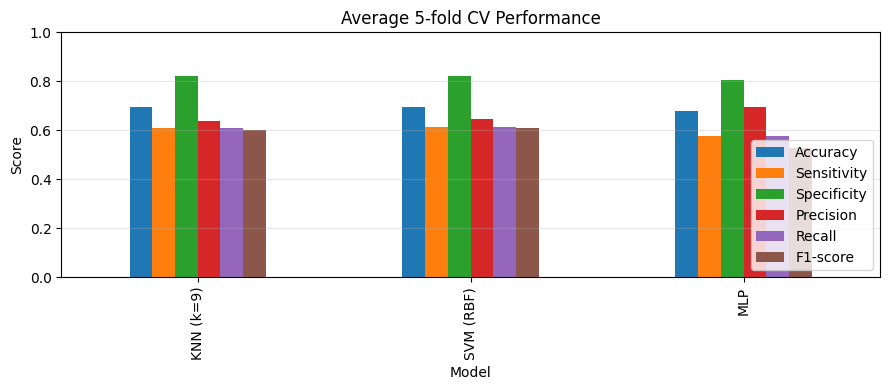

In [60]:

all_results = {
    f"KNN (k={best_k})": knn_results,
    "SVM (RBF)": svm_results,
    "MLP": mlp_results,
}
summary = []
for name, table in all_results.items():
    means = table.drop(columns=["Fold"]).mean()
    stds = table.drop(columns=["Fold"]).std()
    row = {"Model": name}
    for metric in means.index:
        row[metric] = means[metric]
        row[metric + " std"] = stds[metric]
    summary.append(row)

summary_df = pd.DataFrame(summary)
display(summary_df)

summary_df.set_index("Model")[["Accuracy","Sensitivity","Specificity","Precision","Recall","F1-score"]].plot(kind="bar", figsize=(9,4))
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Average 5-fold CV Performance")
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Conclusion
KNN with k=1 achieved the highest average accuracy and F1-score on this dataset. SVM and MLP were more conservative and had more difficulty separating the mid-risk class.